In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [24]:
# Create 'TotalSpending' column (proxy for 'Spending Score')
df['TotalSpending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                      df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Select only numeric columns required for clustering
X = df[['Age', 'Income', 'TotalSpending']]

print("\nSelected Features for Clustering:")
display(X.head())

# Scale the features
scaler = StandardScaler()                # Create StandardScaler object
X_scaled = scaler.fit_transform(X)       # Fit and transform data (mean=0, std=1)

print("\nData Standardized Successfully")
display(pd.DataFrame(X_scaled, columns=X.columns).head())


Selected Features for Clustering:


,Age,Income,TotalSpending
0,69,58138.0,1617
1,72,46344.0,27
2,61,71613.0,776
3,42,26646.0,53
4,45,58293.0,422



Data Standardized Successfully


,Age,Income,TotalSpending
0,0.985345,0.235696,1.679417
1,1.235733,-0.235454,-0.961275
2,0.317643,0.773999,0.282673
3,-1.268149,-1.022355,-0.918094
4,-1.017761,0.241888,-0.305254


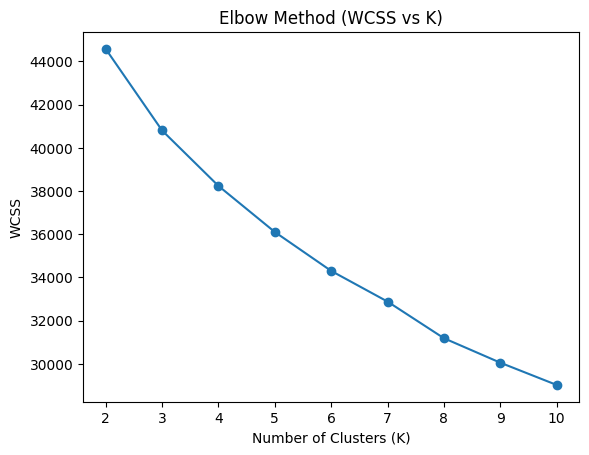

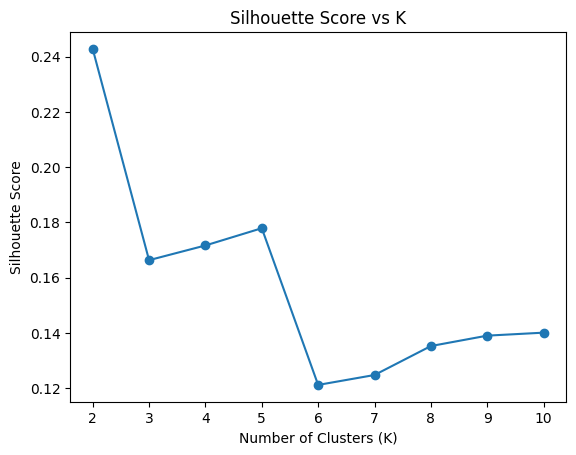


Optimal Number of Clusters: 2

KMeans Evaluation Results:
Silhouette Score: 0.24282043081791663
Davies-Bouldin Score: 1.8448872952540514


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

wcss = []                                # Empty list to store WCSS values
sil_scores = []                          # Empty list to store Silhouette scores
K_range = range(2, 11)                   # Try K values from 2 to 10

# Loop through different K values
for k in K_range:

    kmeans = KMeans(
        n_clusters=k,                    # Number of clusters
        init='k-means++',                # Smart centroid initialization
        n_init=20,                       # Run algorithm 20 times
        random_state=42                  # Fix randomness
    )

    labels = kmeans.fit_predict(X_scaled)  # Fit model and predict clusters

    wcss.append(kmeans.inertia_)           # Store WCSS (inertia_)

    sil = silhouette_score(X_scaled, labels)  # Compute silhouette score
    sil_scores.append(sil)                     # Store silhouette score


plt.figure()                               # Create new figure
plt.plot(K_range, wcss, marker='o')        # Plot K vs WCSS
plt.title("Elbow Method (WCSS vs K)")      # Graph title
plt.xlabel("Number of Clusters (K)")       # X-axis label
plt.ylabel("WCSS")                         # Y-axis label
plt.show()

plt.figure()                               # Create new figure
plt.plot(K_range, sil_scores, marker='o')  # Plot K vs Silhouette score
plt.title("Silhouette Score vs K")         # Graph title
plt.xlabel("Number of Clusters (K)")       # X-axis label
plt.ylabel("Silhouette Score")             # Y-axis label
plt.show()

optimal_k = K_range[np.argmax(sil_scores)]  # Select K with highest silhouette

print("\nOptimal Number of Clusters:", optimal_k)

final_kmeans = KMeans(
    n_clusters=optimal_k,                 # Use optimal K
    init='k-means++',                     # Smart initialization
    n_init=20,                            # 20 runs
    random_state=42                       # Fix seed
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)  # Fit and predict clusters

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)  # Silhouette score
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)      # DB score

print("\nKMeans Evaluation Results:")
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Score:", kmeans_db)

### Hierarchical Clustering: Dendrogram Visualization and Agglomerative Clustering

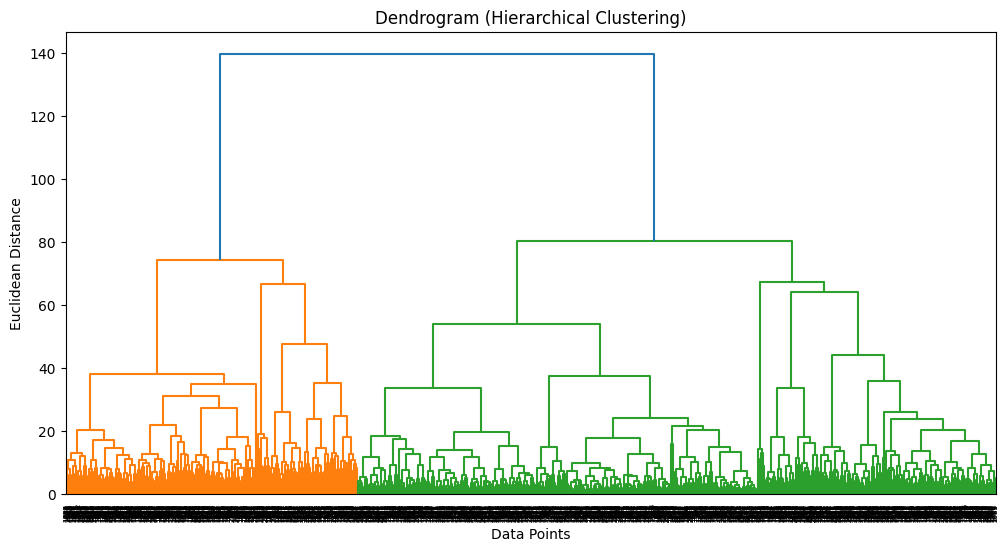


Agglomerative Clustering Results:
Silhouette Score: 0.24099517010582164
Davies-Bouldin Score: 1.9783673414655027


In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(12, 6))                # Create large figure

linkage_matrix = linkage(X_scaled, method='ward')  # Compute linkage matrixprint("\nSelected Features:")
print(X.head())

dendrogram(linkage_matrix)                 # Plot dendrogram

plt.title("Dendrogram (Hierarchical Clustering)")  # Title
plt.xlabel("Data Points")                  # X-axis label
plt.ylabel("Euclidean Distance")           # Y-axis label
plt.show()                                 # Display dendrogram

agglo_model = AgglomerativeClustering(
    n_clusters=optimal_k,                  # Use same optimal K
    linkage='ward'                         # Ward linkage method
)

agglo_labels = agglo_model.fit_predict(X_scaled)  # Fit and predict clusters

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)  # Silhouette
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)      # DB score

print("\nAgglomerative Clustering Results:")
print("Silhouette Score:", agglo_silhouette)
print("Davies-Bouldin Score:", agglo_db)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

# Create 'TotalSpending' column (proxy for 'Spending Score')
df['TotalSpending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                      df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Select only numeric columns required for clustering
X = df[['Age', 'Income', 'TotalSpending']]

print("\nSelected Features for Clustering:")
display(X.head())

# Scale the features
scaler = StandardScaler()                # Create StandardScaler object
X_scaled = scaler.fit_transform(X)       # Fit and transform data (mean=0, std=1)

print("\nData Standardized Successfully")
display(pd.DataFrame(X_scaled, columns=X.columns).head())